In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import tensorflow as tf
from sklearn.model_selection import train_test_split
from AirMLP_Model import *

from sklearn.preprocessing import StandardScaler


## Funções

In [3]:
def createWindows(df, windowSize):

    # Separando as features e o target
    X = df.drop(columns=['valid_at', 'valore_originale', 'pm2p5_y']).values
    y = df['pm2p5_y'].values

    X_sep = []
    y_sep = []

    # 2. Deslizando a janela
    # O "+ 1" garante que a gente pegue a última janela possível no final do dataset
    for i in range(len(X) - windowSize + 1):
        
        # Pega o bloco de 20 linhas e já "amassa" (flatten) para virar um vetor de 120 colunas
        janela_features = X[i : i + windowSize].flatten()
        X_sep.append(janela_features)
        
        # O Alvo (y) é sempre o valor do PM2.5 referente à ÚLTIMA hora dessa janela.
        # O índice da última hora da janela é (i + windowSize - 1)
        alvo = y[i + windowSize - 1]
        y_sep.append(alvo)

    # 3. Convertendo as listas finais para Arrays do NumPy (O formato que a IA gosta)
    X_final = pd.DataFrame(np.array(X_sep))
    y_final = pd.DataFrame(np.array(y_sep))

    return X_final, y_final

In [4]:
def createModelData(Data_Mar_01, Data_Mar_02, Data_Mar_03, Data_Oct_01, Data_Oct_02, windowSize, norm=False):
    # Criando as janelas de dados para cada DataFrame
    X_Mar_01, y_Mar_01 = createWindows(Data_Mar_01, windowSize)
    X_Mar_02, y_Mar_02 = createWindows(Data_Mar_02, windowSize)
    X_Mar_03, y_Mar_03 = createWindows(Data_Mar_03, windowSize)
    X_Oct_01, y_Oct_01 = createWindows(Data_Oct_01, windowSize)
    X_Oct_02, y_Oct_02 = createWindows(Data_Oct_02, windowSize)

    # Concatenando os conjuntos de features (X) e alvos (y) de todos os DataFrames
    X = pd.concat([X_Mar_01, X_Mar_02, X_Mar_03, X_Oct_01, X_Oct_02], ignore_index=True)
    y = pd.concat([y_Mar_01, y_Mar_02, y_Mar_03, y_Oct_01, y_Oct_02], ignore_index=True)

    # Dividindo os dados em conjuntos de treino, validação e teste
    X_train, X_aux, y_train, y_aux = train_test_split(    X,     y, train_size=0.75, random_state=42)
    X_val, X_test, y_val, y_test   = train_test_split(X_aux, y_aux, train_size=0.50, random_state=42)

    X_train.sort_index(inplace=True)
    X_val  .sort_index(inplace=True)
    X_test .sort_index(inplace=True)
    X_aux  .sort_index(inplace=True)

    y_train.sort_index(inplace=True)
    y_val  .sort_index(inplace=True)
    y_test .sort_index(inplace=True)
    y_aux  .sort_index(inplace=True)

    if norm:
        #Normalizando os dados de entrada
        scaler_X = StandardScaler()
        X_train = pd.DataFrame(scaler_X.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
        X_val   = pd.DataFrame(scaler_X.transform(X_val), columns=X_val.columns, index=X_val.index)
        X_test  = pd.DataFrame(scaler_X.transform(X_test), columns=X_test.columns, index=X_test.index)

        #Normalizando os dados de saida
        scaler_y = StandardScaler()
        y_train = pd.DataFrame(scaler_y.fit_transform(y_train.values.reshape(-1, 1)), columns=['target'], index=y_train.index)
        y_val   = pd.DataFrame(scaler_y.transform(y_val.values.reshape(-1, 1)), columns=['target'], index=y_val.index)
        y_test  = pd.DataFrame(scaler_y.transform(y_test.values.reshape(-1, 1)), columns=['target'], index=y_test.index)

    return X_train, y_train, X_val, y_val, X_test, y_test

## Dados

In [5]:
# Carregando os dados
ari_Mar_01 = pd.read_csv('Dados/ari-1727.csv')[::-1].reset_index(drop=True)
ari_Mar_02 = pd.read_csv('Dados/ari-1952.csv')[::-1].reset_index(drop=True)
ari_Mar_03 = pd.read_csv('Dados/ari-1953.csv')[::-1].reset_index(drop=True)
ari_Oct_01 = pd.read_csv('Dados/ari-1885.csv')[::-1].reset_index(drop=True)
ari_Oct_02 = pd.read_csv('Dados/ari-2049.csv')[::-1].reset_index(drop=True)
rf_01      = pd.read_csv('Dados/rf_1.csv')
rf_02      = pd.read_csv('Dados/rf_2.csv')

# Removendo as linhas com valores ausentes
ari_Mar_01.dropna(inplace=True)
ari_Mar_02.dropna(inplace=True)
ari_Mar_03.dropna(inplace=True)
ari_Oct_01.dropna(inplace=True)
ari_Oct_02.dropna(inplace=True)
rf_01     .dropna(inplace=True)
rf_02     .dropna(inplace=True)

# Convertendo a coluna 'valid_at' para o formato datetime
ari_Mar_01['valid_at'] = pd.to_datetime(ari_Mar_01['valid_at'])
ari_Mar_02['valid_at'] = pd.to_datetime(ari_Mar_02['valid_at'])
ari_Mar_03['valid_at'] = pd.to_datetime(ari_Mar_03['valid_at'])
ari_Oct_01['valid_at'] = pd.to_datetime(ari_Oct_01['valid_at'])
ari_Oct_02['valid_at'] = pd.to_datetime(ari_Oct_02['valid_at'])
rf_01     ['valid_at'] = pd.to_datetime(     rf_01['valid_at'])
rf_02     ['valid_at'] = pd.to_datetime(     rf_02['valid_at'])

# Ajustando o horario para o mesmo fuso GMT-0
rf_01['valid_at'] = rf_01['valid_at'] - pd.Timedelta(hours=1)
rf_02['valid_at'] = rf_02['valid_at'] - pd.Timedelta(hours=1)

# Arredondando os horários para o mais próximo possível
ari_Mar_01["valid_at"] = ari_Mar_01["valid_at"].dt.round("h")
ari_Mar_02["valid_at"] = ari_Mar_02["valid_at"].dt.round("h")
ari_Mar_03["valid_at"] = ari_Mar_03["valid_at"].dt.round("h")
ari_Oct_01["valid_at"] = ari_Oct_01["valid_at"].dt.round("h")
ari_Oct_02["valid_at"] = ari_Oct_02["valid_at"].dt.round("h")
rf_01     ["valid_at"] = rf_01     ["valid_at"].dt.round("h")
rf_02     ["valid_at"] = rf_02     ["valid_at"].dt.round("h")

# Realizando o merge dos DataFrames com base na coluna 'valid_at'
Data_Mar_01 = pd.merge(ari_Mar_01, rf_01, on='valid_at', how='inner')
Data_Mar_02 = pd.merge(ari_Mar_02, rf_01, on='valid_at', how='inner')
Data_Mar_03 = pd.merge(ari_Mar_03, rf_01, on='valid_at', how='inner')
Data_Oct_01 = pd.merge(ari_Oct_01, rf_02, on='valid_at', how='inner')
Data_Oct_02 = pd.merge(ari_Oct_02, rf_02, on='valid_at', how='inner')

### Seed aleatória

In [6]:
SEED = 42
random.seed(SEED) # Python
np.random.seed(SEED) # NumPy
tf.random.set_seed(SEED) # TensorFlow

## Otimização

In [7]:
''' PRIMEIRA FASE
params = sample_hyperparameters(winSize_list = [10, 20, 30],
                                hiddenLayer_range=(4, 10),
                                neuron_list=[64, 128, 256, 512],
                                function_list=['relu', 'tanh', 'sigmoid'],
                                learning_rate_range=(-5, -2),
                                batch_size_list=[64, 128, 256, 512]
                                )


'''

" PRIMEIRA FASE\nparams = sample_hyperparameters(winSize_list = [10, 20, 30],\n                                hiddenLayer_range=(4, 10),\n                                neuron_list=[64, 128, 256, 512],\n                                function_list=['relu', 'tanh', 'sigmoid'],\n                                learning_rate_range=(-5, -2),\n                                batch_size_list=[64, 128, 256, 512]\n                                )\n\n\n"

In [8]:
Opt_exp = None

for _ in range(400):
    params = sample_hyperparameters(winSize_list=[20, 30],                  # Removemos o 10, focamos nas janelas mais longas
                                    hiddenLayer_range=(4, 7),               # Redes um pouco mais rasas, evitamos o exagero de 8-10 camadas
                                    neuron_list=[256, 512, 1024],           # Redes mais parrudas (descartamos 64 e 128)
                                    function_list=['relu', 'tanh'],         # Sigmoid foi banida da competição
                                    learning_rate_range=(-4, -2.5),         # Foco logarítmico entre ~0.0001 e ~0.003
                                    batch_size_list=[64, 128]               # Focamos em atualizações de peso mais frequentes
                                    )

    X_train, y_train, X_val, y_val, X_test, y_test = createModelData(Data_Mar_01, Data_Mar_02, Data_Mar_03, Data_Oct_01, Data_Oct_02, params['winSize'], norm=True)

    result = createMLP_andTrain(X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val,
                                hiddenLayers = params['hiddenLayers'],
                                neurons = params['neurons'],
                                function = params['function'],
                                learning_rate = params['learning_rate'],
                                batchSize = params['batchSize'],
                                epochs = params['epochs']
                                )

    if Opt_exp is None:
        Opt_exp = pd.DataFrame([params | result])
    else:
        Opt_exp = pd.concat([Opt_exp, pd.DataFrame([params | result])], ignore_index=True)
    
    Opt_exp.to_csv('Opt_exp_03.csv', index=False)

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
72/72 ━━━━━━━━━━━━━━━━━━━

In [13]:
Opt_exp.sort_values(by='r2', ascending=False).reset_index(drop=True).head(10)

,winSize,hiddenLayers,neurons,function,learning_rate,batchSize,epochs,r2,mae,rmse
0,30,4,1024,relu,0.000352,64,epochs,0.950253,0.124340,0.218130
1,20,4,1024,relu,0.000403,64,epochs,0.948627,0.130934,0.230469
2,30,5,1024,relu,0.000369,128,epochs,0.946890,0.114585,0.225382
3,30,6,1024,relu,0.000200,128,epochs,0.946729,0.115486,0.225725
4,30,7,1024,tanh,0.000135,64,epochs,0.946323,0.139558,0.226583
5,20,5,1024,relu,0.000614,128,epochs,0.945404,0.119217,0.237590
6,20,4,512,relu,0.000577,64,epochs,0.945091,0.140252,0.238270
7,20,5,1024,relu,0.000601,128,epochs,0.945046,0.119120,0.238368
8,30,4,1024,relu,0.000295,64,epochs,0.944894,0.125548,0.229578
9,20,4,1024,relu,0.000573,128,epochs,0.944315,0.132772,0.239948


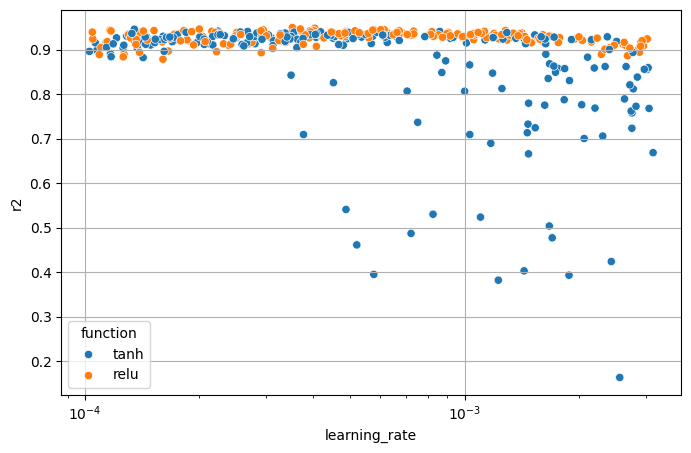

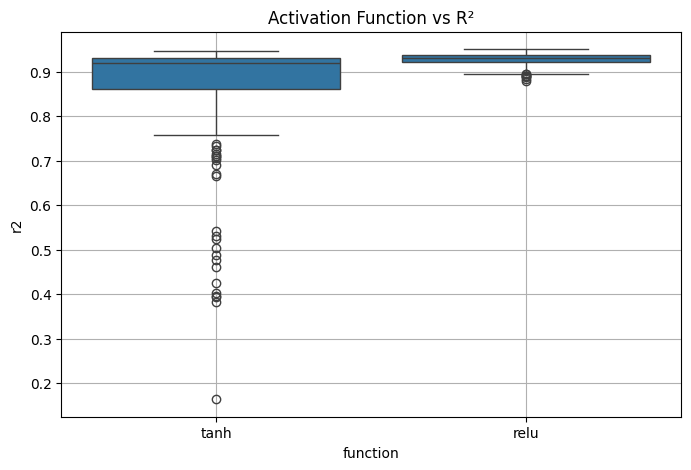

In [10]:

df = Opt_exp

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="learning_rate",
    y="r2",
    hue="function"
)
plt.xscale("log")
plt.grid()
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="function",
    y="r2"
)
plt.grid()
plt.title("Activation Function vs R²")
plt.show()

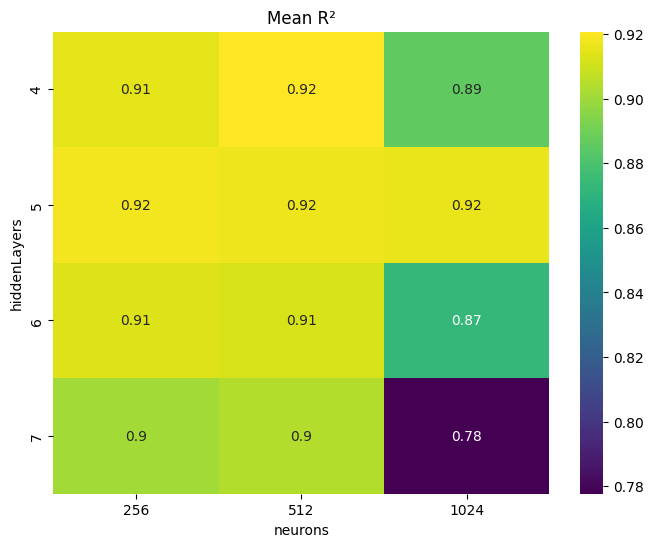

In [11]:
pivot = df.pivot_table(
    values="r2",
    index="hiddenLayers",
    columns="neurons",
    aggfunc="mean"
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, cmap="viridis")

plt.title("Mean R²")
plt.show()

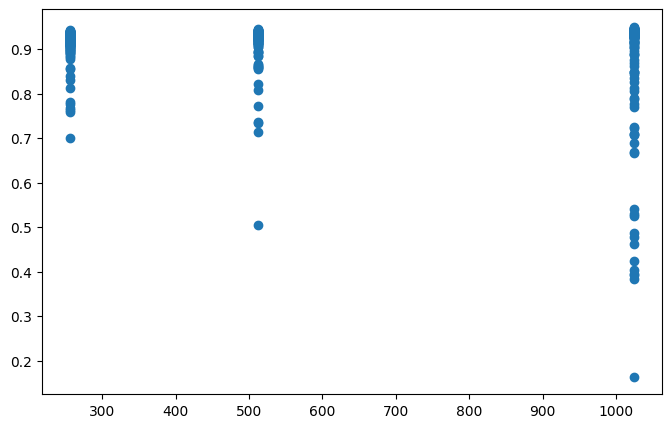

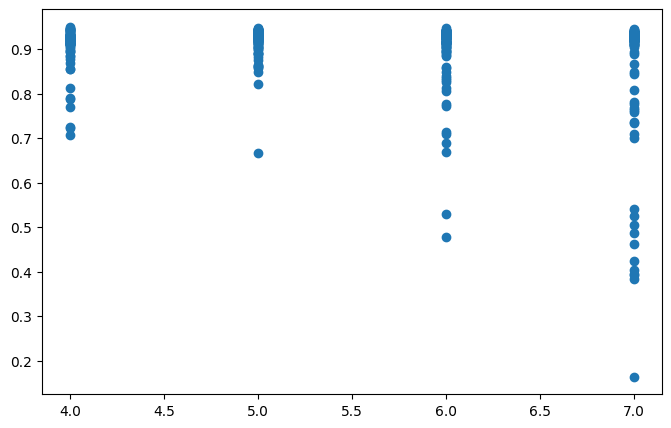

In [12]:
df = Opt_exp.sort_values(by='r2').reset_index(drop=True)

plt.figure(figsize=(8,5))
plt.plot(df['neurons'], df['r2'], 'o')

plt.figure(figsize=(8,5))
plt.plot(df['hiddenLayers'], df['r2'], 'o')